## Input

In [96]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import os
import struct

from typing import Tuple

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [97]:
root_dir = "/Users/ccai/Downloads/SE 489/S4P_MNIST"

train_image_filepath = os.path.join(root_dir, "data", "raw", "train-images.idx3-ubyte")
train_label_filepath = os.path.join(root_dir, "data", "raw", "train-labels.idx1-ubyte")
test_image_filepath = os.path.join(root_dir, "data", "raw", "t10k-images.idx3-ubyte")
test_label_filepath = os.path.join(root_dir, "data", "raw", "t10k-labels.idx1-ubyte")

## Read into np array and visualize

In [98]:
# borrowed from kaggle 

ImageArray = np.ndarray
LabelArray = np.ndarray

class MnistDataloader:

    def __init__(self, 
                 train_image_filepath : str,
                 train_label_filepath : str, 
                 test_image_filepath : str, 
                 test_label_filepath : str) -> None:
        self.train_image_filepath = train_image_filepath
        self.train_label_filepath = train_label_filepath
        self.test_image_filepath = test_image_filepath
        self.test_label_filepath = test_label_filepath

    def read_images_and_labels(self, 
                               images_filepath : str, 
                               labels_filepath : str) -> Tuple[ImageArray, LabelArray]:
        with open(labels_filepath, 'rb') as label_file:
            magic, size = struct.unpack(">II", label_file.read(8))
            if magic != 2049:
                raise ValueError('Magic number mismatch, expected 2049, got {}'.format(magic))

            labels = np.frombuffer(label_file.read(), dtype=np.uint8)

        with open(images_filepath, 'rb') as image_file:
            magic, size, rows, cols = struct.unpack(">IIII", image_file.read(16))
            if magic != 2051:
                raise ValueError('Magic number mismatch, expected 2051, got {}'.format(magic))
            images = np.frombuffer(image_file.read(), dtype=np.uint8).reshape(size, rows * cols)

        return images, labels
    
    def load_data(self) -> Tuple[Tuple[ImageArray, LabelArray], Tuple[ImageArray, LabelArray]]:
        x_train, y_train = self.read_images_and_labels(self.train_image_filepath, self.train_label_filepath)
        x_test, y_test = self.read_images_and_labels(self.test_image_filepath, self.test_label_filepath)
        return (x_train, y_train), (x_test, y_test)
    
mnist_dataloader = MnistDataloader(train_image_filepath, train_label_filepath, test_image_filepath, test_label_filepath)
(x_train, y_train), (x_test, y_test) = mnist_dataloader.load_data()

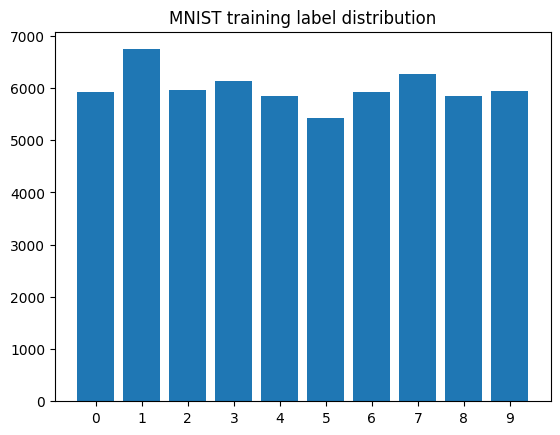

In [99]:
plt.bar(np.arange(10), np.bincount(y_train))
plt.xticks(range(10))
plt.title("MNIST training label distribution")
plt.show()

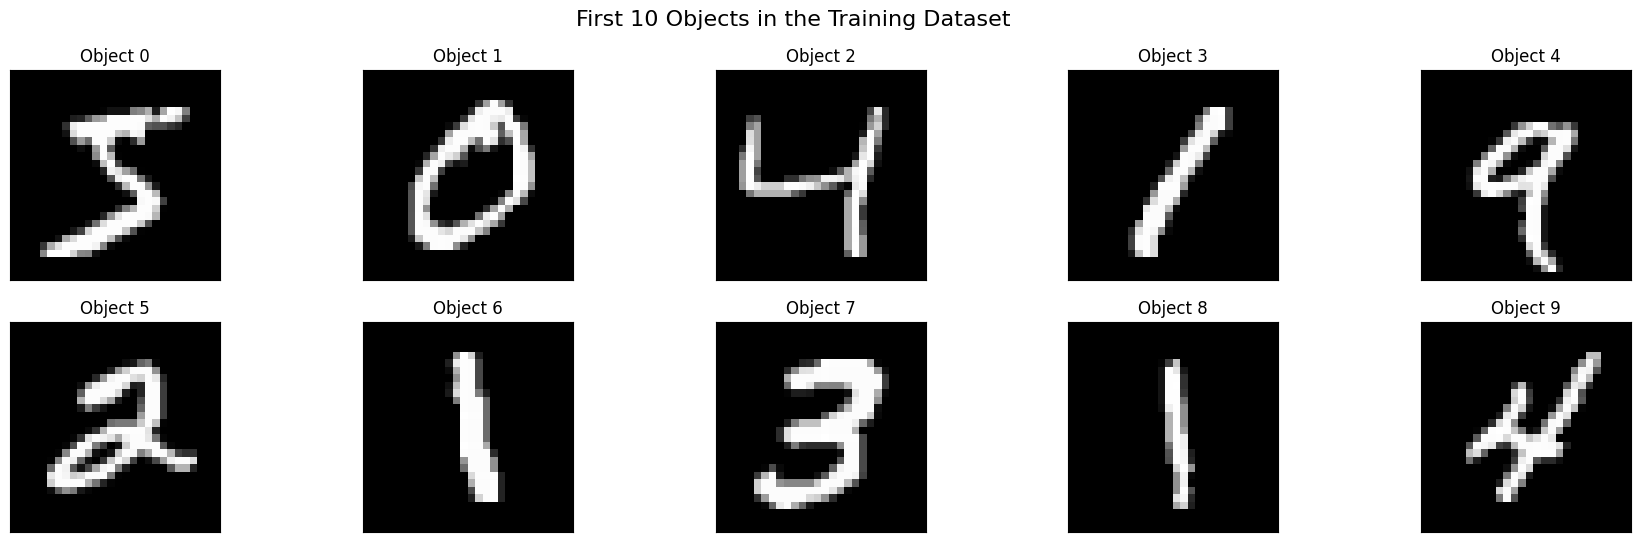

In [100]:
fig, ax = plt.subplots(2, 5, figsize=(22, 6))
ax = ax.flatten()
fig.suptitle('First 10 Objects in the Training Dataset', fontsize=16)
for i in range(10):
    ax[i].imshow(x_train[i].reshape((28, 28)), cmap='gray')
    ax[i].set_xticks([])
    ax[i].set_yticks([])
    ax[i].set_title('Object '+str(i))

plt.show()

## Models

### Logistic Regression

In [101]:
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=100)),
    ("clf", LogisticRegression(max_iter=2000))
])

pipe.fit(x_train, y_train)

y_pred = pipe.predict(x_test)

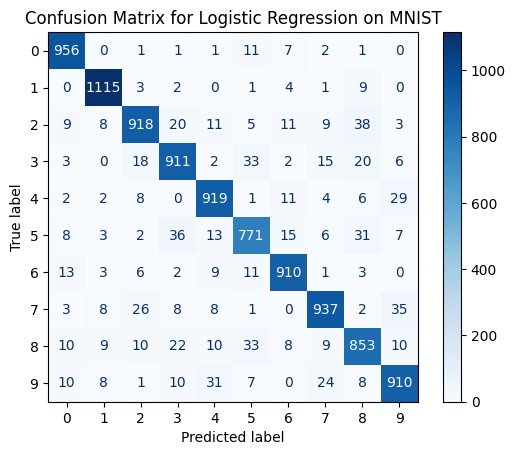

In [102]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.arange(10))
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix for Logistic Regression on MNIST')
plt.show()

In [103]:
cr = classification_report(y_test, y_pred)
print(cr)

              precision    recall  f1-score   support

           0       0.94      0.98      0.96       980
           1       0.96      0.98      0.97      1135
           2       0.92      0.89      0.91      1032
           3       0.90      0.90      0.90      1010
           4       0.92      0.94      0.93       982
           5       0.88      0.86      0.87       892
           6       0.94      0.95      0.94       958
           7       0.93      0.91      0.92      1028
           8       0.88      0.88      0.88       974
           9       0.91      0.90      0.91      1009

    accuracy                           0.92     10000
   macro avg       0.92      0.92      0.92     10000
weighted avg       0.92      0.92      0.92     10000



### KNN

In [104]:
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=100)),
    ("clf", KNeighborsClassifier(n_neighbors=5))
])

pipe.fit(x_train, y_train)

y_pred = pipe.predict(x_test)

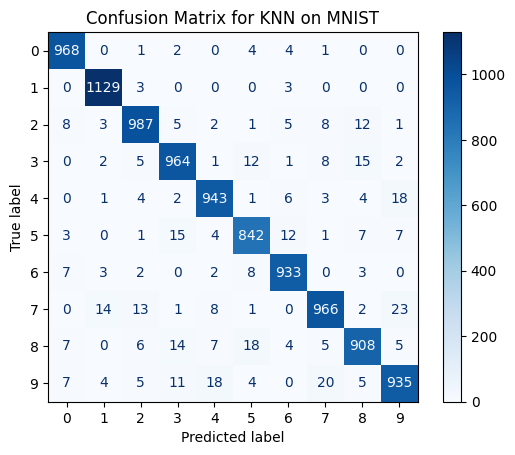

In [105]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.arange(10))
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix for KNN on MNIST')
plt.show()

In [106]:
cr = classification_report(y_test, y_pred)
print(cr)

              precision    recall  f1-score   support

           0       0.97      0.99      0.98       980
           1       0.98      0.99      0.99      1135
           2       0.96      0.96      0.96      1032
           3       0.95      0.95      0.95      1010
           4       0.96      0.96      0.96       982
           5       0.95      0.94      0.94       892
           6       0.96      0.97      0.97       958
           7       0.95      0.94      0.95      1028
           8       0.95      0.93      0.94       974
           9       0.94      0.93      0.94      1009

    accuracy                           0.96     10000
   macro avg       0.96      0.96      0.96     10000
weighted avg       0.96      0.96      0.96     10000



### SVM

In [107]:
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=100)),
    ("clf", SVC())
])

pipe.fit(x_train, y_train)

y_pred = pipe.predict(x_test)

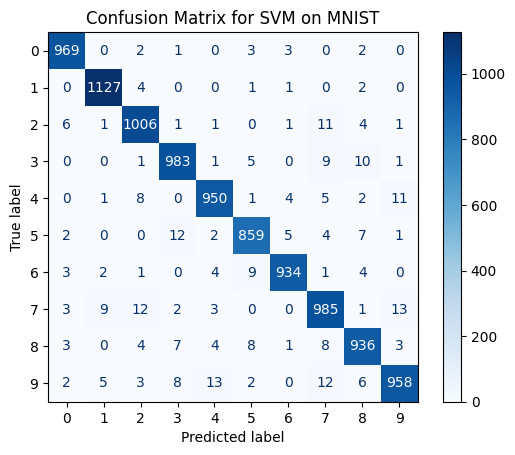

In [108]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.arange(10))
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix for SVM on MNIST')
plt.show()

In [109]:
cr = classification_report(y_test, y_pred)
print(cr)

              precision    recall  f1-score   support

           0       0.98      0.99      0.98       980
           1       0.98      0.99      0.99      1135
           2       0.97      0.97      0.97      1032
           3       0.97      0.97      0.97      1010
           4       0.97      0.97      0.97       982
           5       0.97      0.96      0.97       892
           6       0.98      0.97      0.98       958
           7       0.95      0.96      0.95      1028
           8       0.96      0.96      0.96       974
           9       0.97      0.95      0.96      1009

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000



### Random Forest

In [110]:
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=100)),
    ("clf", RandomForestClassifier(n_estimators=100, random_state=42))
])

pipe.fit(x_train, y_train)

y_pred = pipe.predict(x_test)

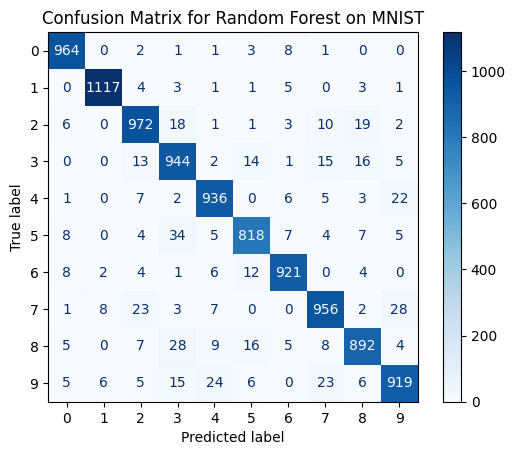

In [111]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.arange(10))
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix for Random Forest on MNIST')
plt.show()

In [112]:
cr = classification_report(y_test, y_pred)
print(cr)

              precision    recall  f1-score   support

           0       0.97      0.98      0.97       980
           1       0.99      0.98      0.99      1135
           2       0.93      0.94      0.94      1032
           3       0.90      0.93      0.92      1010
           4       0.94      0.95      0.95       982
           5       0.94      0.92      0.93       892
           6       0.96      0.96      0.96       958
           7       0.94      0.93      0.93      1028
           8       0.94      0.92      0.93       974
           9       0.93      0.91      0.92      1009

    accuracy                           0.94     10000
   macro avg       0.94      0.94      0.94     10000
weighted avg       0.94      0.94      0.94     10000



### MLP

In [113]:
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=100)),
    ("clf", MLPClassifier(hidden_layer_sizes=(128,64), max_iter=200, random_state=42))
])

pipe.fit(x_train, y_train)

y_pred = pipe.predict(x_test)

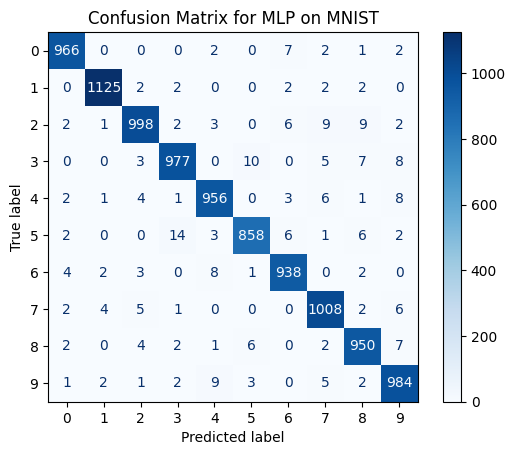

In [114]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.arange(10))
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix for MLP on MNIST')
plt.show()

In [115]:
cr = classification_report(y_test, y_pred)
print(cr)

              precision    recall  f1-score   support

           0       0.98      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.97      0.97      1032
           3       0.98      0.97      0.97      1010
           4       0.97      0.97      0.97       982
           5       0.98      0.96      0.97       892
           6       0.98      0.98      0.98       958
           7       0.97      0.98      0.97      1028
           8       0.97      0.98      0.97       974
           9       0.97      0.98      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000

